d:\week-5\fraud-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📊 Built-in Feature Importance:

SHAP Analysis Starting...
✓ Data loaded: X_train=(219137, 13), X_test=(54785, 13)
✓ Model type: RandomForestClassifier
✓ TreeExplainer created
✓ Sampling 1000 of 54785 rows
🔍 Computing SHAP values...
  SHAP Explanation object with shape: (1000, 13, 2)
  Using positive class (fraud) with shape: (1000, 13)
✓ SHAP computation complete: shape=(1000, 13)

📈 Explainer Statistics:
----------------------------------------
samples_used             : 1000
features                 : 13
shap_values_shape        : (1000, 13)
base_value               : [0.49996041 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041
 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041
 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041
 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041
 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041
 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041 0.49996041
 0.49996041 0.4999604

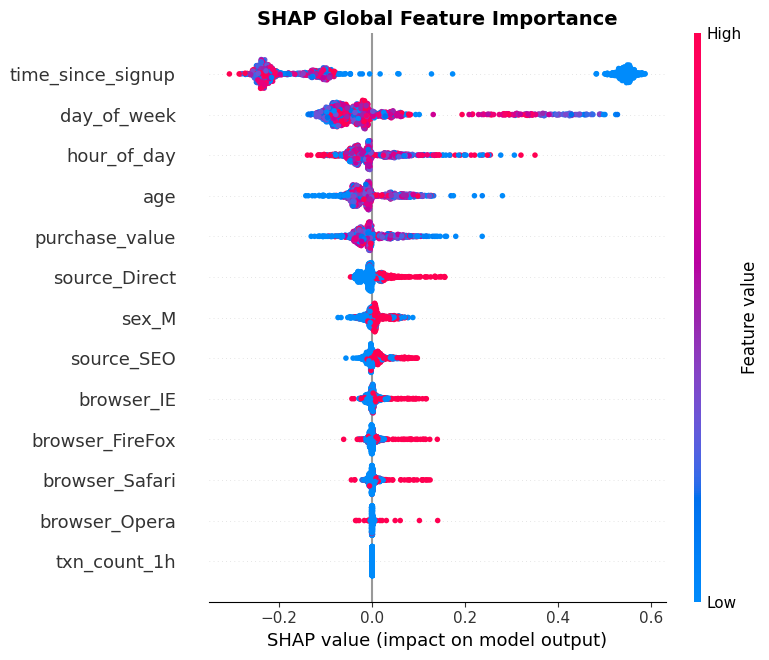

✓ Summary plot created


In [1]:
import joblib
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from scripts.shap_explainability import SHAPExplainer
from src.utils.model_utils import get_feature_importance

# Load RandomForest fraud model
model = joblib.load("../models/fraud_random_forest.joblib")

# Load data
df = pd.read_csv("../data/processed/fraud_balanced_data.csv")

X = df.drop("class", axis=1)
y = df["class"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ------------------------
# Feature importance
# ------------------------
print("📊 Built-in Feature Importance:")
get_feature_importance(model, X.columns)

# ------------------------
# SHAP (Optimized & Fast)
# ------------------------
print("\n" + "="*60)
print("SHAP Analysis Starting...")
print("="*60)

explainer = SHAPExplainer(
    model,
    X_train,
    X_test,
    y_test,
    X.columns,
    sample_size=1000   # Key speed optimization
)

# Get statistics first
explainer.get_stats()

# Global explanations
explainer.summary_plot()


In [4]:
explainer.top_features(10)


📊 Top 10 Features by SHAP Importance:
--------------------------------------------------
          feature  importance  direction
time_since_signup    0.287797        1.0
      day_of_week    0.087871        1.0
      hour_of_day    0.040808       -1.0
              age    0.036663       -1.0
   purchase_value    0.029318       -1.0
    source_Direct    0.018148        1.0
            sex_M    0.014940        1.0
       source_SEO    0.013989        1.0
       browser_IE    0.010088        1.0
  browser_FireFox    0.007897        1.0



,feature,importance,direction
4,time_since_signup,0.287797,1.0
3,day_of_week,0.087871,1.0
2,hour_of_day,0.040808,-1.0
1,age,0.036663,-1.0
0,purchase_value,0.029318,-1.0
6,source_Direct,0.018148,1.0
12,sex_M,0.014940,1.0
7,source_SEO,0.013989,1.0
9,browser_IE,0.010088,1.0
8,browser_FireFox,0.007897,1.0


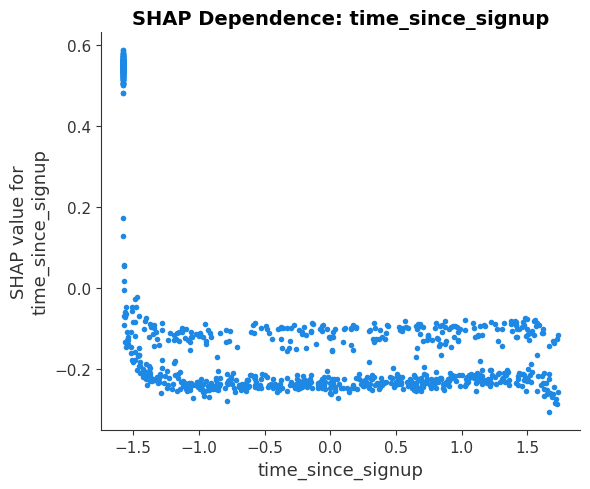

✓ Dependence plot created for 'time_since_signup'


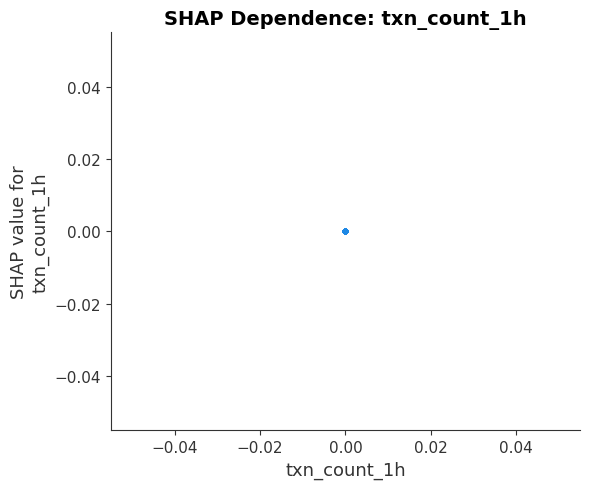

✓ Dependence plot created for 'txn_count_1h'


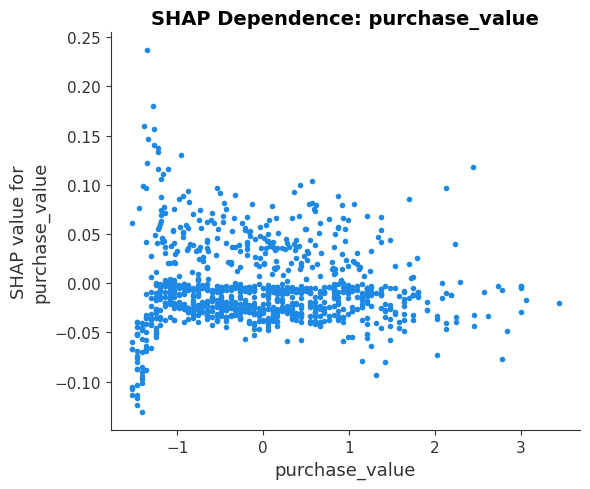

✓ Dependence plot created for 'purchase_value'

🔍 Finding specific cases...
✓ Found TP at index 0 (27037 total TPs)
✓ Found FP at index 971 (25 total FPs)
✓ Found FN at index 60 (355 total FNs)


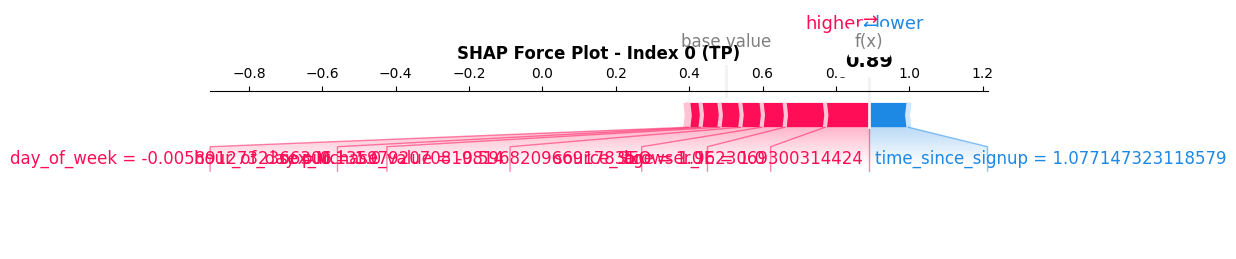

✓ Force plot created for index 0


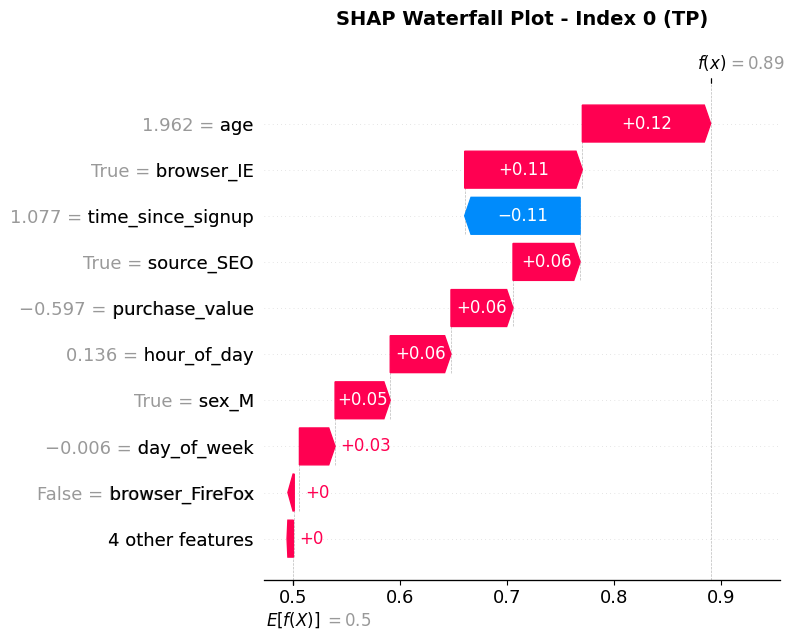

✓ Waterfall plot created for index 0


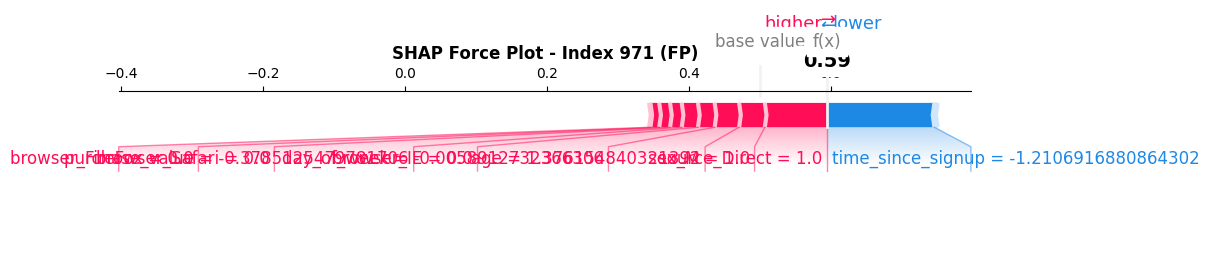

✓ Force plot created for index 971


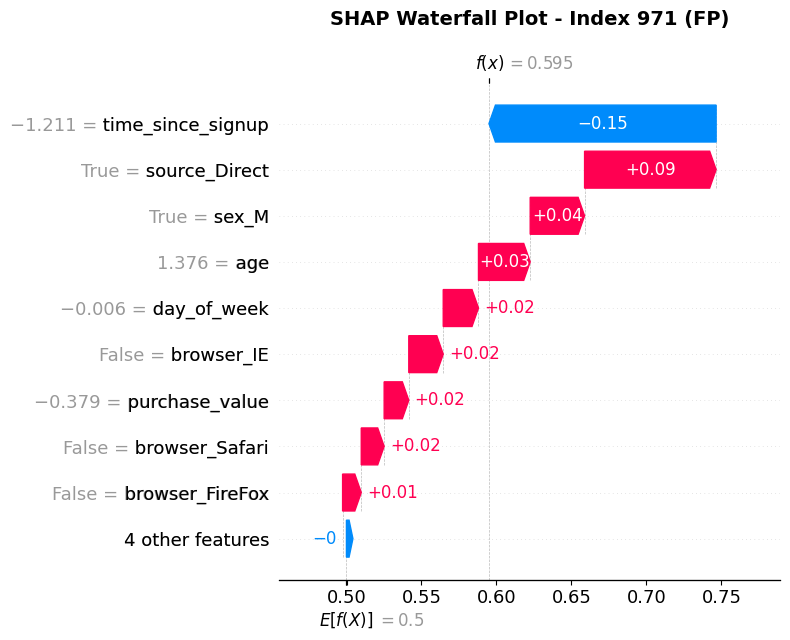

✓ Waterfall plot created for index 971


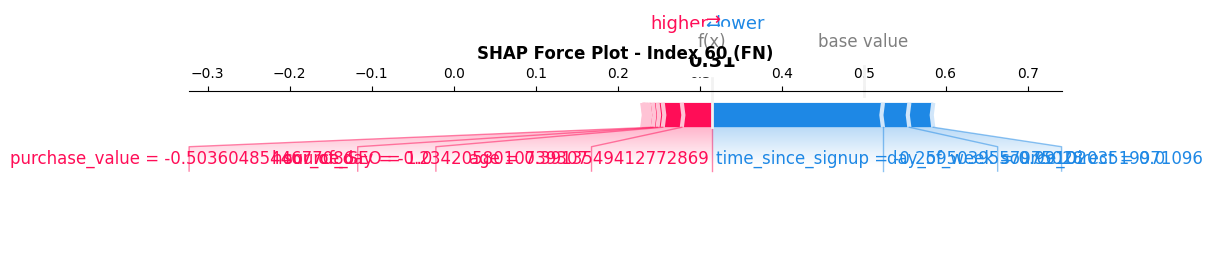

✓ Force plot created for index 60


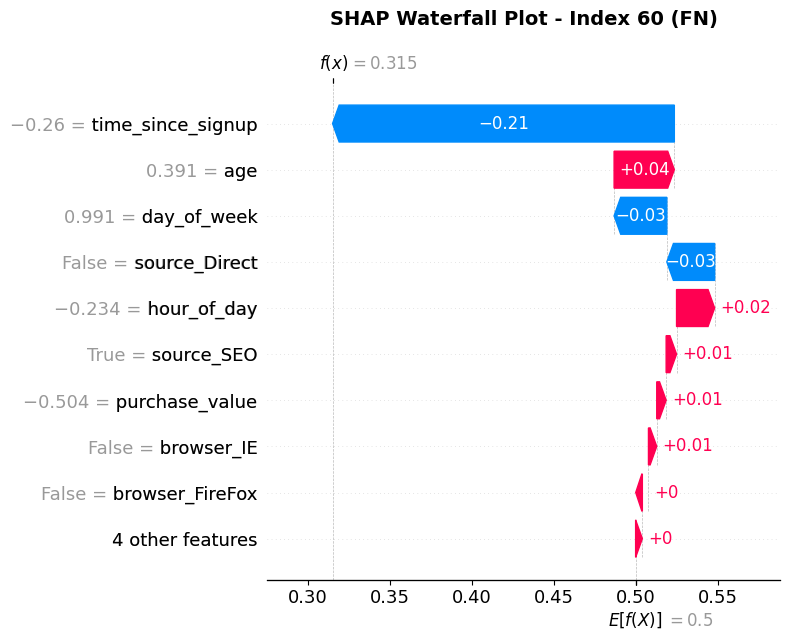

✓ Waterfall plot created for index 60
❌ Decision plot error: Looks like multi output. Try base_value[i] and shap_values[i], or use shap.multioutput_decision_plot().

✅ SHAP analysis complete!


In [2]:


# Dependence plots for key features (FIXED)
for feature in ["time_since_signup", "txn_count_1h", "purchase_value"]:
    if feature in X.columns:
        explainer.dependence_plot(feature)

# Find specific cases
print("\n🔍 Finding specific cases...")
tp = explainer.find_case("TP")
fp = explainer.find_case("FP")
fn = explainer.find_case("FN")

# Local explanations (FIXED for SHAP v0.20+)
if tp is not None:
    explainer.force_plot(tp)
    explainer.waterfall_plot(tp)
    
if fp is not None:
    explainer.force_plot(fp)
    explainer.waterfall_plot(fp)
    
if fn is not None:
    explainer.force_plot(fn)
    explainer.waterfall_plot(fn)

# Bonus: Decision plot comparing cases
explainer.decision_plot([tp, fp, fn] if all(x is not None for x in [tp, fp, fn]) else None)

print("\n✅ SHAP analysis complete!")